# Evasão Escolar no Ensino Médio Brasileiro (2015–2024)

**Projeto G1 — Tema 10 · Notebook de análise exploratória**

| | |
|---|---|
| **Disciplina** | Linguagem de Programação — Análise e Visualização de Dados com Python |
| **Professor** | Alexandre Neves Louzada |
| **Aluno** | Enzo Ribas Torres |

Roteiro: 1. Introdução · 2. Contextualização educacional · 3. Explicação da base · 4. Leitura dos dados ·
5. Limpeza e preparação · 6. Engenharia de atributos · 7. Análise exploratória · 8. KPIs ·
9. Visualizações · 10. Persistência em banco (SQLAlchemy + SQLite) · 11. Interpretação dos resultados · 12. Conclusão

## 1. Introdução

Este notebook investiga os padrões de **evasão escolar no ensino médio brasileiro entre 2015 e 2024**. O objetivo é
transformar uma base de dados em respostas para sete perguntas orientadoras:

1. Quais estados apresentam maior evasão escolar?
2. Existem regiões mais vulneráveis?
3. A evasão aumentou ou diminuiu ao longo do tempo?
4. Há diferenças entre escolas públicas e privadas?
5. Existe relação entre renda e evasão?
6. Quais séries apresentam maior abandono?
7. Quais fatores parecem mais associados ao problema?

As análises daqui alimentam o dashboard Streamlit (`app.py`), que permite explorar os mesmos resultados com filtros interativos.

## 2. Contextualização educacional

A evasão escolar é um dos principais desafios da educação brasileira. O abandono do ensino médio tem impacto direto sobre
**empregabilidade**, **desigualdade econômica**, **qualidade da educação**, **inclusão social** e **desenvolvimento do país**.

A literatura aponta diversos fatores associados ao problema: condições socioeconômicas das famílias, necessidade de trabalhar,
distância e acesso à escola, desempenho acadêmico (reprovação e distorção idade-série), infraestrutura e desigualdades
regionais. Medir onde e em que grupos a evasão se concentra é o primeiro passo para direcionar políticas de permanência.

## 3. Explicação da base

A base `simulacao_evasao_escolar_brasil.csv` é **simulada** e foi fornecida pelo professor. Cada linha resume um
**município × rede de ensino × série** em um **semestre**.

| Coluna | Descrição |
|---|---|
| `ano`, `semestre`, `data` | Ano letivo, semestre (1 ou 2) e data de referência |
| `regiao`, `uf`, `municipio` | Localização |
| `rede_ensino` | Pública ou Privada |
| `serie` | 1º, 2º ou 3º ano do ensino médio |
| `matriculados`, `evasoes` | Total de alunos matriculados e de evasões |
| `taxa_evasao` | Percentual de evasão (evasões ÷ matriculados × 100) |
| `renda_media_familiar` | Renda média estimada das famílias (R$) |
| `indice_desempenho` | Índice acadêmico médio (0–100) |
| `acesso_internet` | Percentual de alunos com acesso digital |
| `nivel_risco` | Classificação da taxa: Baixo, Médio, Alto, Crítico |

Além do CSV, o projeto consome a **API de dados do IBGE** (nome oficial, código e malha geográfica dos estados).

## 4. Leitura dos dados

In [1]:
import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DADOS = RAIZ / "dados"
IMAGENS = RAIZ / "imagens"
IMAGENS.mkdir(exist_ok=True)

# Paleta fixa: a cor acompanha a entidade em todos os gráficos
CORES_REDE = {"Pública": "#2a78d6", "Privada": "#eb6834"}
CORES_REGIAO = {"Norte": "#2a78d6", "Nordeste": "#eb6834", "Centro-Oeste": "#1baf7a", "Sudeste": "#eda100", "Sul": "#e87ba4"}
CORES_RISCO = {"Baixo": "#0ca30c", "Médio": "#fab219", "Alto": "#ec835a", "Crítico": "#d03b3b"}
AZUIS = LinearSegmentedColormap.from_list("azul", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
DIVERGENTE = LinearSegmentedColormap.from_list("div", ["#d03b3b", "#f0efec", "#2a78d6"])
PCT = mtick.FuncFormatter(lambda v, _: f"{v:.0f}%")

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlesize": 13, "grid.color": "#e1e0d9",
    "legend.frameon": False, "figure.dpi": 100,
})
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

df_bruto = pd.read_csv(DADOS / "simulacao_evasao_escolar_brasil.csv", encoding="utf-8-sig")
print(f"{df_bruto.shape[0]} linhas x {df_bruto.shape[1]} colunas")
df_bruto.head()

1480 linhas x 15 colunas


,ano,semestre,data,regiao,uf,municipio,rede_ensino,serie,matriculados,evasoes,taxa_evasao,renda_media_familiar,indice_desempenho,acesso_internet,nivel_risco
0,2015,1,2015-06-01,Norte,AM,Manaus,Pública,3º ano,38388,3604,9.39,"3,302.32",66.53,87.50,Alto
1,2015,1,2015-06-01,Norte,AM,Manaus,Privada,3º ano,34326,979,2.85,"2,323.55",85.59,64.60,Baixo
2,2015,1,2015-06-01,Norte,PA,Belém,Pública,1º ano,22029,2461,11.18,"2,728.75",80.67,82.60,Alto
3,2015,1,2015-06-01,Norte,PA,Belém,Privada,2º ano,45187,1483,3.28,"4,389.77",68.68,61.80,Baixo
4,2015,1,2015-06-01,Norte,PA,Santarém,Pública,3º ano,37786,4071,10.77,"2,100.56",36.26,73.00,Alto


In [2]:
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ano                   1480 non-null   int64  
 1   semestre              1480 non-null   int64  
 2   data                  1480 non-null   str    
 3   regiao                1480 non-null   str    
 4   uf                    1480 non-null   str    
 5   municipio             1480 non-null   str    
 6   rede_ensino           1480 non-null   str    
 7   serie                 1480 non-null   str    
 8   matriculados          1480 non-null   int64  
 9   evasoes               1480 non-null   int64  
 10  taxa_evasao           1480 non-null   float64
 11  renda_media_familiar  1480 non-null   float64
 12  indice_desempenho     1480 non-null   float64
 13  acesso_internet       1480 non-null   float64
 14  nivel_risco           1480 non-null   str    
dtypes: float64(4), int64(4), str(7)


## 5. Limpeza e preparação

Verificações realizadas: nulos, duplicados, tipos, registros impossíveis, coerência da taxa e intervalos válidos dos índices.

In [3]:
print("Valores nulos por coluna:")
print(df_bruto.isna().sum().to_string())
print("\nLinhas duplicadas:", df_bruto.duplicated().sum())
print("Registros com evasões > matriculados:", (df_bruto["evasoes"] > df_bruto["matriculados"]).sum())

Valores nulos por coluna:
ano                     0
semestre                0
data                    0
regiao                  0
uf                      0
municipio               0
rede_ensino             0
serie                   0
matriculados            0
evasoes                 0
taxa_evasao             0
renda_media_familiar    0
indice_desempenho       0
acesso_internet         0
nivel_risco             0

Linhas duplicadas: 0
Registros com evasões > matriculados: 0


In [4]:
# A taxa informada deve ser igual a evasões ÷ matriculados
taxa_calculada = (df_bruto["evasoes"] / df_bruto["matriculados"] * 100).round(2)
divergentes = (taxa_calculada - df_bruto["taxa_evasao"]).abs() > 0.05
print(f"Taxas divergentes do cálculo: {divergentes.sum()}")
df_bruto.loc[divergentes, ["municipio", "matriculados", "evasoes", "taxa_evasao"]].assign(taxa_calculada=taxa_calculada[divergentes]).head(8)

Taxas divergentes do cálculo: 16


,municipio,matriculados,evasoes,taxa_evasao,taxa_calculada
175,Brasília,714,12,1.76,1.68
225,Belém,1025,22,2.23,2.15
230,Palmas,801,96,12.08,11.99
284,Curitiba,977,111,11.43,11.36
396,Brasília,1006,59,5.94,5.86
593,Manaus,799,23,2.97,2.88
613,Juazeiro do Norte,1362,6,0.50,0.44
728,Curitiba,1135,107,9.51,9.43


In [5]:
# Índices percentuais fora de 0–100
fora = df_bruto[(df_bruto["indice_desempenho"] > 100) | (df_bruto["acesso_internet"] > 100)
                | (df_bruto["indice_desempenho"] < 0) | (df_bruto["acesso_internet"] < 0)]
fora[["municipio", "ano", "semestre", "indice_desempenho", "acesso_internet"]]

,municipio,ano,semestre,indice_desempenho,acesso_internet
1080,Niterói,2022,1,102.22,62.40
1172,Curitiba,2022,2,101.07,85.70


In [6]:
df = df_bruto.copy()

# Padronização de textos e tipos
for col in ["regiao", "uf", "municipio", "rede_ensino", "serie", "nivel_risco"]:
    df[col] = df[col].astype(str).str.strip()
df["uf"] = df["uf"].str.upper()
df["data"] = pd.to_datetime(df["data"])

# Remoção de duplicados e registros impossíveis (nenhum encontrado, mas a regra fica documentada)
df = df.drop_duplicates()
df = df[(df["matriculados"] > 0) & (df["evasoes"].between(0, df["matriculados"]))]

# Correção: recalcula a taxa a partir da fonte primária (evasões e matriculados)
df["taxa_evasao"] = (df["evasoes"] / df["matriculados"] * 100).round(2)

# Correção: limita os índices ao intervalo válido
df["indice_desempenho"] = df["indice_desempenho"].clip(0, 100)
df["acesso_internet"] = df["acesso_internet"].clip(0, 100)

# Categorias ordenadas (melhora ordenação em tabelas e gráficos)
df["regiao"] = pd.Categorical(df["regiao"], ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"], ordered=True)
df["rede_ensino"] = pd.Categorical(df["rede_ensino"], ["Pública", "Privada"], ordered=True)
df["serie"] = pd.Categorical(df["serie"], ["1º ano", "2º ano", "3º ano"], ordered=True)
df["nivel_risco"] = pd.Categorical(df["nivel_risco"], ["Baixo", "Médio", "Alto", "Crítico"], ordered=True)

print(f"Base tratada: {len(df)} linhas · {divergentes.sum()} taxas corrigidas · {len(fora)} índices ajustados")

Base tratada: 1480 linhas · 16 taxas corrigidas · 2 índices ajustados


In [7]:
# Conferência: o nível de risco segue faixas fixas da taxa de evasão
df.groupby("nivel_risco", observed=True)["taxa_evasao"].agg(["min", "max", "count"])

,min,max,count
nivel_risco,,,
Baixo,0.42,4.00,340
Médio,4.00,7.99,464
Alto,8.00,12.99,593
Crítico,13.03,16.30,83


**Resultado da limpeza:** a base não tinha nulos nem duplicados, mas **16 taxas** não batiam com evasões ÷ matriculados
(erros de arredondamento de até 0,14 p.p.) e **2 índices de desempenho** passavam de 100. Ambos foram corrigidos.
O nível de risco segue faixas fixas: Baixo < 4%, Médio 4–8%, Alto 8–13% e Crítico ≥ 13%.

## 6. Engenharia de atributos

- `periodo`: rótulo ano-semestre para as séries temporais;
- `permanencias`: alunos que não evadiram;
- quartis de renda, desempenho e acesso à internet;
- **integração com a API do IBGE**: nome oficial do estado e código IBGE (usado no mapa do dashboard).

Uma decisão importante: **taxas agregadas são sempre ponderadas pelas matrículas** (soma das evasões ÷ soma dos
matriculados). A média simples das taxas daria o mesmo peso a um registro com 400 alunos e a outro com 49 mil.

In [8]:
df["periodo"] = df["ano"].astype(str) + "-S" + df["semestre"].astype(str)
df["permanencias"] = df["matriculados"] - df["evasoes"]

rotulos = ["Q1 (mais baixo)", "Q2", "Q3", "Q4 (mais alto)"]
df["faixa_renda"] = pd.qcut(df["renda_media_familiar"], 4, labels=rotulos)
df["faixa_desempenho"] = pd.qcut(df["indice_desempenho"], 4, labels=rotulos)
df["faixa_internet"] = pd.qcut(df["acesso_internet"], 4, labels=rotulos)

# Consumo da API do IBGE com Requests (com cópia local como contingência)
try:
    resposta = requests.get("https://servicodados.ibge.gov.br/api/v1/localidades/estados", timeout=15)
    resposta.raise_for_status()
    estados = pd.DataFrame([{"codigo_ibge": e["id"], "uf": e["sigla"], "nome": e["nome"], "regiao": e["regiao"]["nome"]}
                            for e in resposta.json()])
    print("Estados obtidos da API do IBGE:", len(estados))
except requests.RequestException:
    estados = pd.DataFrame(json.loads((DADOS / "ibge_estados.json").read_text(encoding="utf-8")))
    print("API indisponível: usando cópia local")

df = df.merge(estados[["uf", "nome", "codigo_ibge"]].rename(columns={"nome": "nome_uf"}), on="uf", how="left")
print("UFs sem correspondência no IBGE:", df["nome_uf"].isna().sum())

# Conferência cruzada: a região do CSV bate com a região oficial do IBGE?
confere = df[["uf", "regiao"]].drop_duplicates().merge(estados[["uf", "regiao"]], on="uf", suffixes=("_csv", "_ibge"))
print("Regiões divergentes:", (confere["regiao_csv"].astype(str) != confere["regiao_ibge"]).sum())


def taxa_ponderada(dados, por):
    agg = dados.groupby(por, observed=True)[["evasoes", "matriculados"]].sum()
    agg["taxa_evasao"] = agg["evasoes"] / agg["matriculados"] * 100
    return agg.reset_index()


df[["periodo", "uf", "nome_uf", "codigo_ibge", "rede_ensino", "serie", "taxa_evasao", "faixa_renda"]].head()

Estados obtidos da API do IBGE: 27
UFs sem correspondência no IBGE: 0
Regiões divergentes: 0


,periodo,uf,nome_uf,codigo_ibge,rede_ensino,serie,taxa_evasao,faixa_renda
0,2015-S1,AM,Amazonas,13,Pública,3º ano,9.39,Q4 (mais alto)
1,2015-S1,AM,Amazonas,13,Privada,3º ano,2.85,Q1 (mais baixo)
2,2015-S1,PA,Pará,15,Pública,1º ano,11.17,Q2
3,2015-S1,PA,Pará,15,Privada,2º ano,3.28,Q4 (mais alto)
4,2015-S1,PA,Pará,15,Pública,3º ano,10.77,Q1 (mais baixo)


## 7. Análise exploratória

In [9]:
df[["matriculados", "evasoes", "taxa_evasao", "renda_media_familiar", "indice_desempenho", "acesso_internet"]].describe().T

,count,mean,std,min,25%,50%,75%,max
matriculados,"1,480.00","25,564.54","14,300.33",393.00,"12,961.75","26,093.50","37,807.25","49,989.00"
evasoes,"1,480.00","1,850.20","1,485.76",3.00,648.25,"1,474.50","2,763.75","6,943.00"
taxa_evasao,"1,480.00",7.26,3.72,0.42,4.16,7.30,10.41,16.30
renda_media_familiar,"1,480.00","2,807.68",673.74,462.35,"2,358.02","2,822.60","3,275.56","4,618.80"
indice_desempenho,"1,480.00",64.72,11.87,32.72,56.64,64.53,72.49,100.00
acesso_internet,"1,480.00",69.75,14.51,45.10,56.90,69.95,82.12,94.90


In [10]:
cobertura = pd.DataFrame({
    "Anos": [df["ano"].nunique()], "Semestres": [df["periodo"].nunique()], "Regiões": [df["regiao"].nunique()],
    "Estados": [df["uf"].nunique()], "Municípios": [df["municipio"].nunique()], "Registros": [len(df)],
})
cobertura

,Anos,Semestres,Regiões,Estados,Municípios,Registros
0,10,20,5,20,37,1480


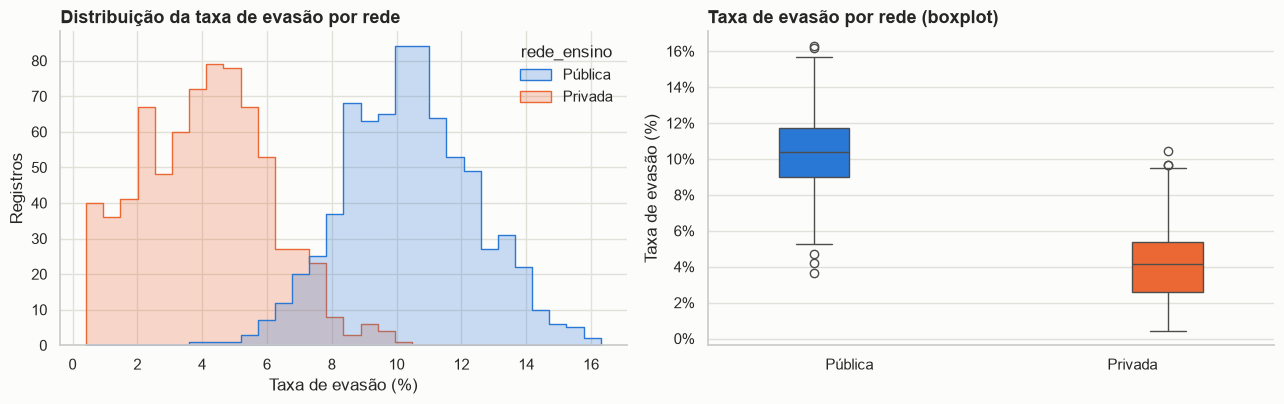

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.histplot(data=df, x="taxa_evasao", hue="rede_ensino", palette=CORES_REDE, bins=30, element="step", ax=axes[0])
axes[0].set_title("Distribuição da taxa de evasão por rede")
axes[0].set_xlabel("Taxa de evasão (%)")
axes[0].set_ylabel("Registros")
sns.boxplot(data=df, x="rede_ensino", y="taxa_evasao", hue="rede_ensino", palette=CORES_REDE, saturation=1,
            width=0.5, legend=False, ax=axes[1])
axes[1].set_title("Taxa de evasão por rede (boxplot)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Taxa de evasão (%)")
axes[1].yaxis.set_major_formatter(PCT)
fig.tight_layout()
fig.savefig(IMAGENS / "distribuicao_rede.png", dpi=150, bbox_inches="tight")
plt.show()

A distribuição é **bimodal**: as duas redes formam grupos quase separados. A maior parte dos registros da rede privada fica abaixo de 8%,
enquanto a pública se concentra entre 8% e 13%. Esse é o primeiro indício de que a rede de ensino é a variável que mais separa os registros.

In [12]:
pd.crosstab(df["rede_ensino"], df["nivel_risco"], margins=True, margins_name="Total")

nivel_risco,Baixo,Médio,Alto,Crítico,Total
rede_ensino,,,,,
Pública,1,84,572,83,740
Privada,339,380,21,0,740
Total,340,464,593,83,1480


## 8. KPIs

In [13]:
taxa_media = df["evasoes"].sum() / df["matriculados"].sum() * 100
por_uf = taxa_ponderada(df, ["uf", "nome_uf"]).sort_values("taxa_evasao", ascending=False)
por_regiao = taxa_ponderada(df, "regiao").sort_values("taxa_evasao", ascending=False)
por_rede = taxa_ponderada(df, "rede_ensino").sort_values("taxa_evasao", ascending=False)
por_serie = taxa_ponderada(df, "serie").sort_values("taxa_evasao", ascending=False)

kpis = pd.DataFrame([
    ("Taxa média de evasão (ponderada)", f"{taxa_media:.2f}%"),
    ("Taxa média simples (referência)", f"{df['taxa_evasao'].mean():.2f}%"),
    ("Total de evasões", f"{df['evasoes'].sum():,}".replace(",", ".")),
    ("Estado com maior evasão", f"{por_uf.iloc[0]['nome_uf']} ({por_uf.iloc[0]['taxa_evasao']:.2f}%)"),
    ("Região mais vulnerável", f"{por_regiao.iloc[0]['regiao']} ({por_regiao.iloc[0]['taxa_evasao']:.2f}%)"),
    ("Rede mais afetada", f"{por_rede.iloc[0]['rede_ensino']} ({por_rede.iloc[0]['taxa_evasao']:.2f}%)"),
    ("Série mais crítica", f"{por_serie.iloc[0]['serie']} ({por_serie.iloc[0]['taxa_evasao']:.2f}%)"),
    ("Razão pública ÷ privada", f"{por_rede.iloc[0]['taxa_evasao'] / por_rede.iloc[1]['taxa_evasao']:.2f}x"),
    ("Registros em risco Crítico", f"{(df['nivel_risco'] == 'Crítico').mean() * 100:.1f}%"),
], columns=["KPI", "Valor"])
kpis

,KPI,Valor
0,Taxa média de evasão (ponderada),7.24%
1,Taxa média simples (referência),7.26%
2,Total de evasões,2.738.301
3,Estado com maior evasão,Distrito Federal (7.93%)
4,Região mais vulnerável,Centro-Oeste (7.49%)
5,Rede mais afetada,Pública (10.43%)
6,Série mais crítica,3º ano (7.35%)
7,Razão pública ÷ privada,2.53x
8,Registros em risco Crítico,5.6%


## 9. Visualizações

### 9.1 Linha temporal: evolução da evasão

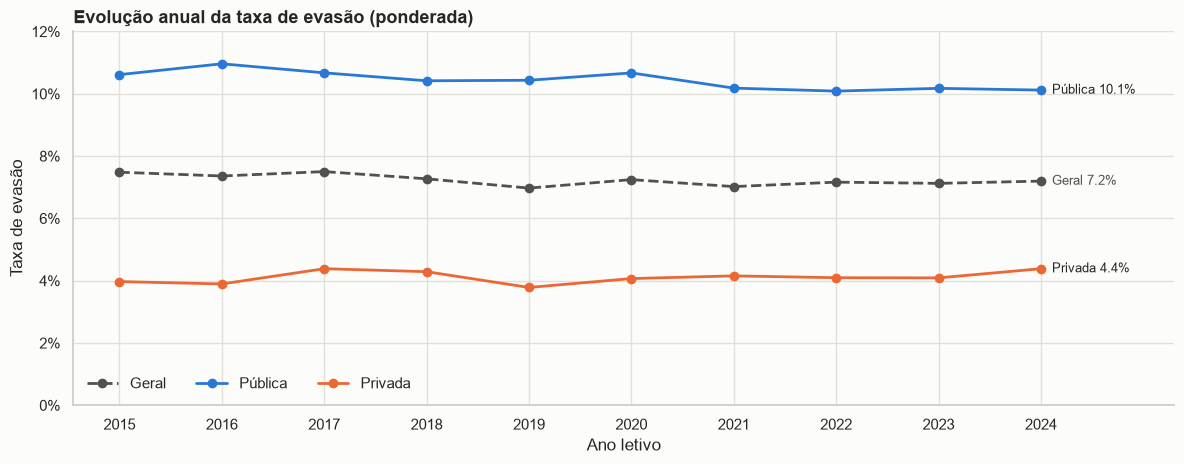

Tendência linear (numpy.polyfit): -0.039 p.p. por ano


,ano,evasoes,matriculados,taxa_evasao,variacao_pp,media_movel_3a
0,2015,303432,4055300,7.48,NaN,7.48
1,2016,257201,3494355,7.36,-0.12,7.42
2,2017,286706,3821647,7.50,0.14,7.45
3,2018,296187,4074163,7.27,-0.23,7.38
4,2019,247058,3543542,6.97,-0.30,7.25
5,2020,275569,3804000,7.24,0.27,7.16
6,2021,256948,3659930,7.02,-0.22,7.08
7,2022,293800,4101498,7.16,0.14,7.14
8,2023,253718,3561474,7.12,-0.04,7.10
9,2024,267682,3719609,7.20,0.07,7.16


In [14]:
anual = taxa_ponderada(df, "ano")
anual_rede = taxa_ponderada(df, ["ano", "rede_ensino"])

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(anual["ano"], anual["taxa_evasao"], color="#52514e", ls="--", lw=2, marker="o", label="Geral")
for rede, cor in CORES_REDE.items():
    serie = anual_rede[anual_rede["rede_ensino"] == rede]
    ax.plot(serie["ano"], serie["taxa_evasao"], color=cor, lw=2, marker="o", label=rede)
    ax.annotate(f"{rede} {serie['taxa_evasao'].iloc[-1]:.1f}%", (serie["ano"].iloc[-1], serie["taxa_evasao"].iloc[-1]),
                xytext=(8, 0), textcoords="offset points", va="center", fontsize=9)
ax.annotate(f"Geral {anual['taxa_evasao'].iloc[-1]:.1f}%", (anual["ano"].iloc[-1], anual["taxa_evasao"].iloc[-1]),
            xytext=(8, 0), textcoords="offset points", va="center", fontsize=9, color="#52514e")
ax.set_title("Evolução anual da taxa de evasão (ponderada)")
ax.set_xlabel("Ano letivo")
ax.set_ylabel("Taxa de evasão")
ax.set_xticks(anual["ano"])
ax.set_ylim(0, 12)
ax.set_xlim(right=2025.3)
ax.yaxis.set_major_formatter(PCT)
ax.legend(loc="lower left", ncol=3)
fig.tight_layout()
fig.savefig(IMAGENS / "evolucao_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

inclinacao = np.polyfit(anual["ano"], anual["taxa_evasao"], 1)[0]
anual["variacao_pp"] = anual["taxa_evasao"].diff()
anual["media_movel_3a"] = anual["taxa_evasao"].rolling(3, min_periods=1).mean()
print(f"Tendência linear (numpy.polyfit): {inclinacao:+.3f} p.p. por ano")
anual

A evasão geral caiu de 7,48% (2015) para 7,20% (2024), uma **tendência de −0,039 p.p./ano**: queda lenta, quase
estagnação. O menor valor foi em 2019 (6,97%) e **2020, ano da pandemia, interrompeu a melhora** (+0,27 p.p.).
A rede pública ficou entre 5,7 e 7,1 p.p. acima da privada em todos os anos: a desigualdade é estrutural.

### 9.2 Heatmap semestral: evolução temporal por região

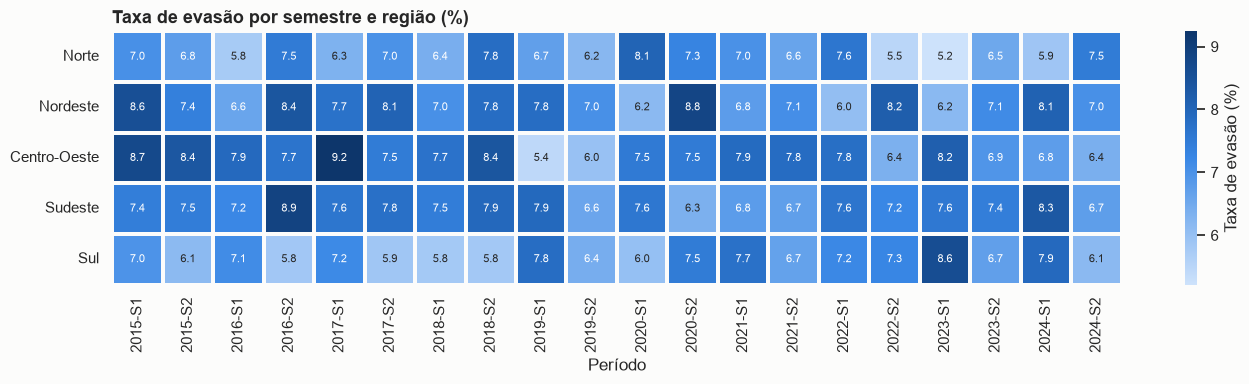

Semestres mais críticos:


,periodo,evasoes,matriculados,taxa_evasao
3,2016-S2,129182,1652107,7.82
0,2015-S1,158157,2047527,7.72
18,2024-S1,151778,1988058,7.63


In [15]:
tabela = taxa_ponderada(df, ["regiao", "periodo"]).pivot(index="regiao", columns="periodo", values="taxa_evasao")
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(tabela, cmap=AZUIS, annot=True, fmt=".1f", annot_kws={"fontsize": 8}, linewidths=1.5, linecolor="#fcfcfb",
            cbar_kws={"label": "Taxa de evasão (%)"}, ax=ax)
ax.set_title("Taxa de evasão por semestre e região (%)")
ax.set_xlabel("Período")
ax.set_ylabel("")
ax.grid(False)
fig.tight_layout()
fig.savefig(IMAGENS / "heatmap_semestral.png", dpi=150, bbox_inches="tight")
plt.show()

print("Semestres mais críticos:")
taxa_ponderada(df, "periodo").sort_values("taxa_evasao", ascending=False).head(3)

Os semestres oscilam sem padrão sazonal fixo (1º e 2º semestres têm médias de 7,29% e 7,18%). Os períodos mais
críticos foram **2016-S2, 2015-S1 e 2024-S1**. Picos isolados, como o Centro-Oeste em 2017-S1 (9,2%), sugerem
choques locais e reforçam a utilidade de um monitoramento semestral.

### 9.3 Barras por estado: comparação regional

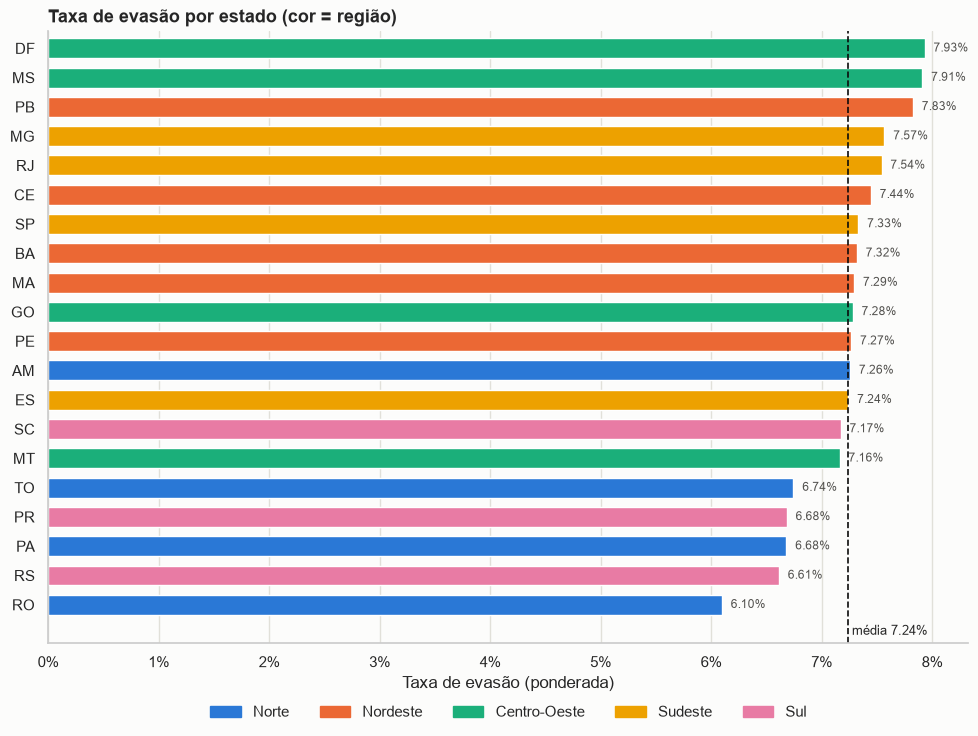

In [16]:
ranking = taxa_ponderada(df, ["uf", "regiao"]).sort_values("taxa_evasao")
fig, ax = plt.subplots(figsize=(10, 7.5))
ax.barh(ranking["uf"], ranking["taxa_evasao"], color=[CORES_REGIAO[str(r)] for r in ranking["regiao"]], height=0.68)
for y, v in enumerate(ranking["taxa_evasao"]):
    ax.text(v + 0.08, y, f"{v:.2f}%", va="center", fontsize=8.5, color="#52514e")
ax.axvline(taxa_media, color="#0b0b0b", ls="--", lw=1.2)
ax.text(taxa_media, -0.9, f" média {taxa_media:.2f}%", fontsize=9, va="center")
ax.set_ylim(-1.3, len(ranking) - 0.4)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in CORES_REGIAO.values()], labels=list(CORES_REGIAO),
          loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=5)
ax.set_title("Taxa de evasão por estado (cor = região)")
ax.set_xlabel("Taxa de evasão (ponderada)")
ax.xaxis.set_major_formatter(PCT)
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(IMAGENS / "ranking_estados.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
regiao_rede = taxa_ponderada(df, ["regiao", "rede_ensino"]).pivot(index="regiao", columns="rede_ensino", values="taxa_evasao")
regiao_rede["Geral"] = taxa_ponderada(df, "regiao").set_index("regiao")["taxa_evasao"]
regiao_rede.sort_values("Geral", ascending=False)

rede_ensino,Pública,Privada,Geral
regiao,,,
Centro-Oeste,10.35,4.38,7.49
Sudeste,10.51,4.31,7.43
Nordeste,10.79,3.99,7.40
Sul,10.02,3.92,6.81
Norte,10.15,3.83,6.70


**Distrito Federal (7,93%), Mato Grosso do Sul (7,91%) e Paraíba (7,83%)** lideram; **Rondônia (6,10%)** tem a menor taxa.
A amplitude entre estados é de 1,83 p.p. Entre regiões, **Centro-Oeste (7,49%)** é a mais vulnerável, seguida de perto
por Sudeste e Nordeste; **Norte (6,70%)** e Sul (6,81%) são as menos afetadas. Estados da mesma região aparecem
espalhados pelo ranking, e dentro de cada região a rede pública continua com taxa 2,3 a 2,7 vezes maior que a privada.

### 9.4 Barras por série: comparação escolar

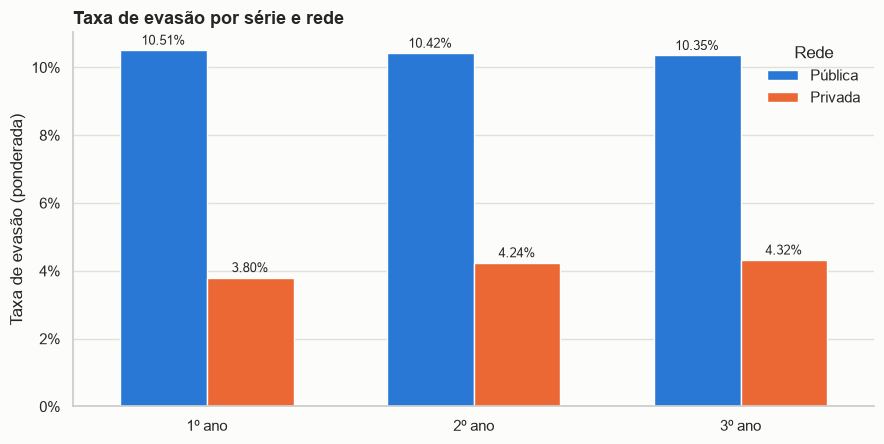

,Pública,Privada,taxa_geral
serie,,,
1º ano,51.50,48.50,7.26
2º ano,46.30,53.70,7.10
3º ano,50.20,49.80,7.35


In [18]:
serie_rede = taxa_ponderada(df, ["serie", "rede_ensino"])
fig, ax = plt.subplots(figsize=(9, 4.6))
sns.barplot(data=serie_rede, x="serie", y="taxa_evasao", hue="rede_ensino", palette=CORES_REDE, saturation=1, width=0.65, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", fontsize=9, padding=2)
ax.set_title("Taxa de evasão por série e rede")
ax.set_xlabel("")
ax.set_ylabel("Taxa de evasão (ponderada)")
ax.yaxis.set_major_formatter(PCT)
ax.legend(title="Rede")
fig.tight_layout()
fig.savefig(IMAGENS / "series_rede.png", dpi=150, bbox_inches="tight")
plt.show()

composicao = (pd.crosstab(df["serie"], df["rede_ensino"], values=df["matriculados"], aggfunc="sum", normalize="index") * 100).round(1)
composicao.join(taxa_ponderada(df, "serie").set_index("serie")["taxa_evasao"].rename("taxa_geral"))

No agregado, o **3º ano** tem a maior taxa (7,35%), mas a diferença entre séries é de só 0,25 p.p. Dentro de cada
rede o quadro se inverte: na **pública o 1º ano é o mais crítico (10,51%)**, enquanto na privada é o 3º ano (4,32%).
A tabela de composição (% das matrículas de cada série por rede) mostra que o peso das redes é parecido nas três séries
(46% a 52% de matrículas públicas), então ele não explica o ranking. O 3º ano lidera no agregado porque reúne a maior
taxa da rede privada (4,32%) e uma taxa pública também alta (10,35%). Conclusão: **a série mais crítica depende da rede**,
e as diferenças entre séries (≤ 0,7 p.p. dentro de cada rede) são pequenas perto da diferença entre redes (≈ 6 p.p.).

### 9.5 Dispersão renda × evasão: correlação

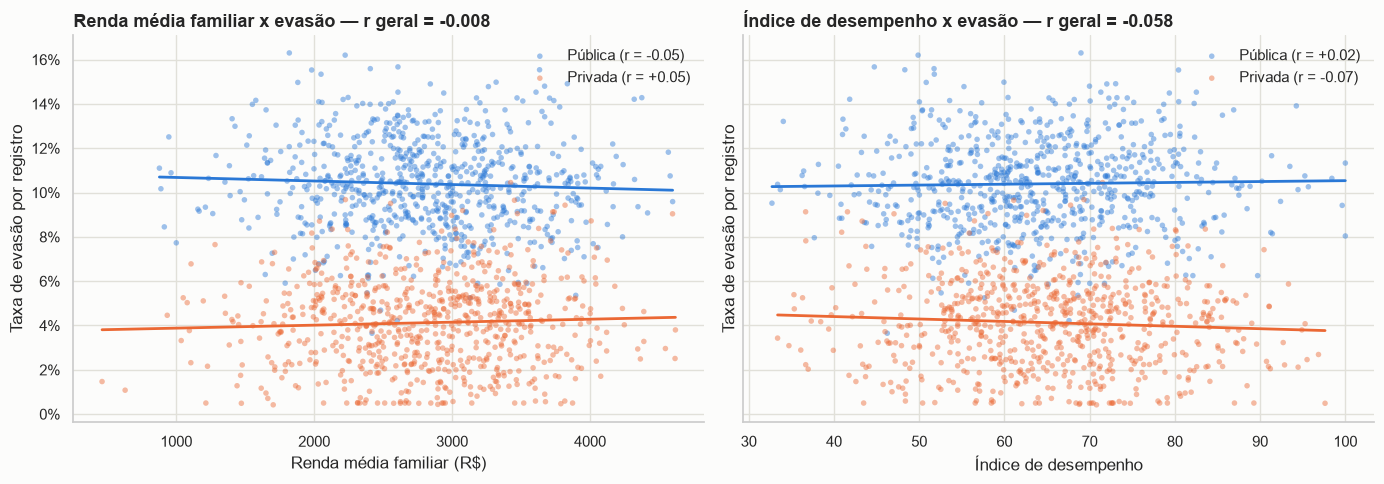

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (coluna, titulo) in zip(axes, [("renda_media_familiar", "Renda média familiar (R$)"),
                                       ("indice_desempenho", "Índice de desempenho")]):
    for rede, cor in CORES_REDE.items():
        sub = df[df["rede_ensino"] == rede]
        r = sub[coluna].corr(sub["taxa_evasao"])
        sns.regplot(data=sub, x=coluna, y="taxa_evasao", color=cor, ci=None, ax=ax,
                    scatter_kws={"s": 16, "alpha": 0.45, "edgecolor": "none"}, line_kws={"lw": 2}, label=f"{rede} (r = {r:+.2f})")
    ax.set_title(f"{titulo.split(' (')[0]} x evasão — r geral = {df[coluna].corr(df['taxa_evasao']):+.3f}")
    ax.set_xlabel(titulo)
    ax.set_ylabel("Taxa de evasão por registro")
    ax.yaxis.set_major_formatter(PCT)
    ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(IMAGENS / "dispersao_renda_desempenho.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
fatores = {
    "Rede pública (1 = sim)": (df["rede_ensino"] == "Pública").astype(int),
    "Renda média familiar": df["renda_media_familiar"],
    "Índice de desempenho": df["indice_desempenho"],
    "Acesso à internet": df["acesso_internet"],
}
linhas = []
for nome, x in fatores.items():
    r = x.corr(df["taxa_evasao"])
    t = r * math.sqrt((len(df) - 2) / (1 - r**2))
    linhas.append({
        "Fator": nome,
        "Pearson": r,
        "Spearman": x.rank().corr(df["taxa_evasao"].rank()),  # Spearman = Pearson sobre os postos
        "p-valor (aprox.)": math.erfc(abs(t) / math.sqrt(2)),
        "r na Pública": np.nan if nome.startswith("Rede") else x[df["rede_ensino"] == "Pública"].corr(df.loc[df["rede_ensino"] == "Pública", "taxa_evasao"]),
        "r na Privada": np.nan if nome.startswith("Rede") else x[df["rede_ensino"] == "Privada"].corr(df.loc[df["rede_ensino"] == "Privada", "taxa_evasao"]),
    })
correlacoes = pd.DataFrame(linhas).set_index("Fator")
correlacoes.style.format("{:+.3f}").format("{:.4f}", subset=["p-valor (aprox.)"])

,Pearson,Spearman,p-valor (aprox.),r na Pública,r na Privada
Fator,,,,,
Rede pública (1 = sim),+0.843,+0.842,0.0000,+nan,+nan
Renda média familiar,-0.008,-0.019,0.7462,-0.053,+0.046
Índice de desempenho,-0.058,-0.052,0.0263,+0.023,-0.066
Acesso à internet,-0.029,-0.027,0.2575,-0.039,-0.022


In [21]:
quartis = pd.concat({
    "Renda": taxa_ponderada(df, "faixa_renda").set_index("faixa_renda")["taxa_evasao"],
    "Desempenho": taxa_ponderada(df, "faixa_desempenho").set_index("faixa_desempenho")["taxa_evasao"],
    "Internet": taxa_ponderada(df, "faixa_internet").set_index("faixa_internet")["taxa_evasao"],
}, axis=1)
quartis.index.name = "Quartil"
quartis

,Renda,Desempenho,Internet
Quartil,,,
Q1 (mais baixo),7.18,7.51,7.28
Q2,7.41,7.22,7.65
Q3,7.21,7.14,6.84
Q4 (mais alto),7.15,7.07,7.18


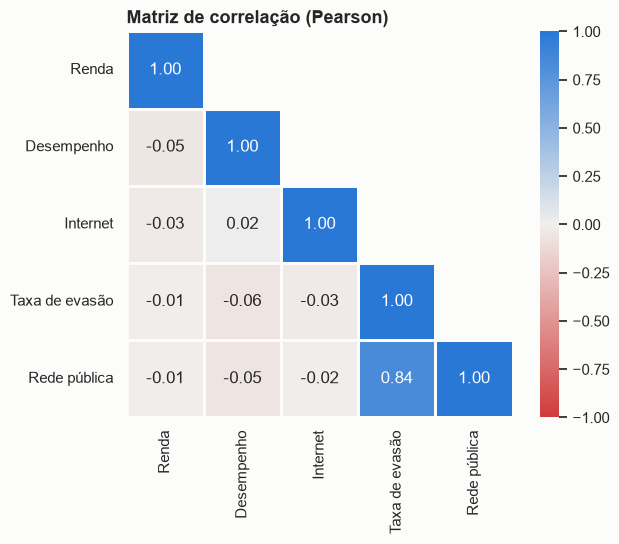

In [22]:
base_corr = df[["renda_media_familiar", "indice_desempenho", "acesso_internet", "taxa_evasao"]].copy()
base_corr["rede_publica"] = (df["rede_ensino"] == "Pública").astype(int)
base_corr.columns = ["Renda", "Desempenho", "Internet", "Taxa de evasão", "Rede pública"]
corr = base_corr.corr()

fig, ax = plt.subplots(figsize=(7, 5.6))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), cmap=DIVERGENTE, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", square=True, linewidths=2, linecolor="#fcfcfb", ax=ax)
ax.set_title("Matriz de correlação (Pearson)")
ax.grid(False)
fig.tight_layout()
fig.savefig(IMAGENS / "matriz_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()

**Não há relação entre renda e evasão nesta base** (r = −0,008; a taxa fica entre 7,15% e 7,41% em todos os quartis).
Acesso à internet também é desprezível. O desempenho tem uma correlação negativa fraca no agregado
(r = −0,058, p ≈ 0,03; do 1º ao 4º quartil a taxa cai de 7,51% para 7,07%), mas o sinal **não se mantém dentro das redes**
(+0,02 na pública, −0,07 na privada): boa parte do efeito vem de a rede privada ter desempenho médio um pouco maior.

O fator dominante é a **rede de ensino** (correlação ponto-bisserial r = 0,84). Nos gráficos de dispersão, as retas
das duas redes são praticamente horizontais e separadas por um degrau de cerca de 6 p.p.

### 9.6 Nível de risco por rede

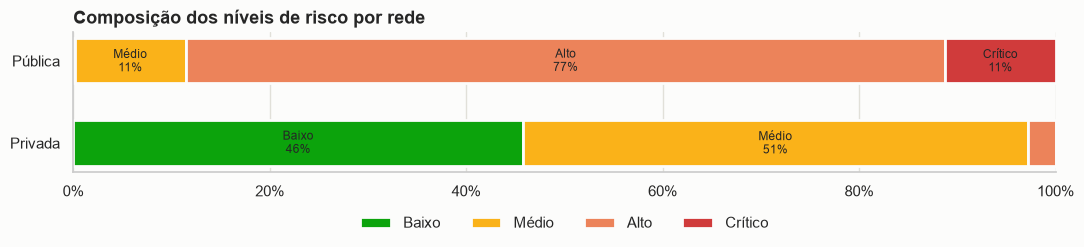

In [23]:
composicao_risco = pd.crosstab(df["rede_ensino"], df["nivel_risco"], normalize="index") * 100
fig, ax = plt.subplots(figsize=(11, 2.8))
esquerda = np.zeros(len(composicao_risco))
for nivel in composicao_risco.columns:
    valores = composicao_risco[nivel].to_numpy()
    ax.barh(composicao_risco.index.astype(str), valores, left=esquerda, color=CORES_RISCO[nivel], label=nivel, height=0.55,
            edgecolor="#fcfcfb", linewidth=2)
    for y, (v, x0) in enumerate(zip(valores, esquerda)):
        if v >= 6:
            ax.text(x0 + v / 2, y, f"{nivel}\n{v:.0f}%", ha="center", va="center", fontsize=8.5)
    esquerda += valores
ax.set_title("Composição dos níveis de risco por rede")
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PCT)
ax.invert_yaxis()
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.22))
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(IMAGENS / "risco_rede.png", dpi=150, bbox_inches="tight")
plt.show()

**Todos os 83 registros críticos são da rede pública**, e apenas 1 registro público está em risco Baixo. Na rede
privada, 97% dos registros estão em risco Baixo ou Médio.

### 9.7 Tabela dinâmica: exploração detalhada

In [24]:
dinamica = df.pivot_table(index="regiao", columns=["rede_ensino", "serie"], values=["evasoes", "matriculados"],
                          aggfunc="sum", observed=True)
taxa_dinamica = (dinamica["evasoes"] / dinamica["matriculados"] * 100).round(2)
taxa_dinamica.style.background_gradient(cmap=AZUIS, axis=None).format("{:.2f}")

## 10. Persistência em banco (SQLAlchemy + SQLite)

A base tratada é gravada em `database/evasao_escolar.sqlite` com **modelagem relacional** (SQLAlchemy ORM), usando o
mesmo módulo do dashboard (`src/banco.py`):

`regioes (1) ── (N) estados (1) ── (N) municipios (1) ── (N) indicadores_evasao`

In [25]:
sys.path.insert(0, str(RAIZ))
from sqlalchemy import inspect, text

from src.banco import construir_banco

engine = construir_banco(df, estados)
inspetor = inspect(engine)
for tabela in inspetor.get_table_names():
    with engine.connect() as conexao:
        n = conexao.execute(text(f"SELECT COUNT(*) FROM {tabela}")).scalar()
    print(f"{tabela:<20} {n:>5} linhas · FKs: {[fk['referred_table'] for fk in inspetor.get_foreign_keys(tabela)]}")

estados                 20 linhas · FKs: ['regioes']
indicadores_evasao    1480 linhas · FKs: ['municipios']
municipios              37 linhas · FKs: ['estados']
regioes                  5 linhas · FKs: []


In [26]:
consulta = '''
SELECT r.nome AS regiao,
       ROUND(100.0 * SUM(CASE WHEN i.rede_ensino = 'Pública' THEN i.evasoes END)
                   / SUM(CASE WHEN i.rede_ensino = 'Pública' THEN i.matriculados END), 2) AS taxa_publica,
       ROUND(100.0 * SUM(CASE WHEN i.rede_ensino = 'Privada' THEN i.evasoes END)
                   / SUM(CASE WHEN i.rede_ensino = 'Privada' THEN i.matriculados END), 2) AS taxa_privada,
       ROUND(100.0 * SUM(i.evasoes) / SUM(i.matriculados), 2) AS taxa_geral
FROM indicadores_evasao i
JOIN municipios m ON m.id = i.municipio_id
JOIN estados e    ON e.uf = m.uf
JOIN regioes r    ON r.id = e.regiao_id
GROUP BY r.nome
ORDER BY taxa_geral DESC
'''
with engine.connect() as conexao:
    resultado_sql = pd.read_sql(text(consulta), conexao)
resultado_sql

,regiao,taxa_publica,taxa_privada,taxa_geral
0,Centro-Oeste,10.35,4.38,7.49
1,Sudeste,10.51,4.31,7.43
2,Nordeste,10.79,3.99,7.40
3,Sul,10.02,3.92,6.81
4,Norte,10.15,3.83,6.70


In [27]:
# Exporta também a base tratada em CSV para consulta
colunas = ["ano", "semestre", "periodo", "data", "regiao", "uf", "nome_uf", "codigo_ibge", "municipio", "rede_ensino", "serie",
           "matriculados", "evasoes", "permanencias", "taxa_evasao", "renda_media_familiar", "indice_desempenho",
           "acesso_internet", "nivel_risco", "faixa_renda", "faixa_desempenho", "faixa_internet"]
df[colunas].to_csv(DADOS / "evasao_escolar_tratada.csv", index=False, encoding="utf-8-sig")
print("Arquivos gerados:", sorted(p.name for p in IMAGENS.glob("*.png")))

Arquivos gerados: ['dispersao_renda_desempenho.png', 'distribuicao_rede.png', 'evolucao_temporal.png', 'heatmap_semestral.png', 'matriz_correlacao.png', 'ranking_estados.png', 'risco_rede.png', 'series_rede.png']


## 11. Interpretação dos resultados

| Pergunta | Resposta |
|---|---|
| Quais estados apresentam maior evasão? | **DF (7,93%), MS (7,91%) e PB (7,83%)**. Menor: RO (6,10%). Amplitude de 1,83 p.p. |
| Existem regiões mais vulneráveis? | Sim, mas com diferença moderada: **Centro-Oeste (7,49%)**, Sudeste (7,43%) e Nordeste (7,40%) contra Sul (6,81%) e Norte (6,70%). |
| A evasão aumentou ou diminuiu? | **Diminuiu pouco**: 7,48% → 7,20% (−0,039 p.p./ano). 2020 interrompeu a melhora. |
| Pública × privada? | **Maior diferença da base**: 10,43% contra 4,12%, taxa **2,5 vezes maior** na pública, em todos os anos, regiões e séries. |
| Renda e evasão? | **Sem relação** (r = −0,008). A taxa é praticamente igual em todos os quartis de renda. |
| Quais séries têm maior abandono? | Diferenças pequenas. Na rede pública, o **1º ano** é o mais crítico (10,51%). |
| Fatores mais associados? | **Rede de ensino** (r = 0,84). Desempenho tem associação fraca e inconsistente; renda e internet, desprezível. |

**Leitura crítica.** Em dados reais, renda e desempenho costumam estar fortemente associados à evasão. Nesta base simulada
essas variáveis foram geradas de forma praticamente independente da taxa, e a rede de ensino concentra todo o sinal.
Um bom resultado analítico aqui é **não inventar relações que os dados não mostram**.

## 12. Conclusão

Entre 2015 e 2024, **2.738.301 estudantes** abandonaram o ensino médio na base analisada (taxa ponderada de **7,24%**).
O problema é **persistente**, pois a taxa caiu menos de 0,3 p.p. em dez anos, e está **concentrado na rede pública**,
onde a taxa é 2,5 vezes a da privada e estão todos os registros em risco crítico. A desigualdade entre redes é muito maior
que a desigualdade entre estados, regiões ou séries.

**Recomendações:** priorizar programas de permanência na rede pública, com atenção especial ao 1º ano; monitorar os
indicadores semestralmente para reagir a choques locais; e ampliar a coleta para variáveis que esta base não cobre
(trabalho juvenil, distância até a escola, infraestrutura), já que renda e acesso digital não explicam a variação observada.

**Limitações:** a base é simulada, a análise é descritiva (correlação não implica causalidade) e os registros são agregados
por município, rede e série, sem dados individuais de estudantes.

O dashboard Streamlit (`app.py`) permite explorar todos esses resultados com filtros por ano, semestre, região, estado,
rede, série e nível de risco.